# 1. Data and Data Preprocess

## column names

In [267]:
import pandas as pd

df = pd.read_csv('/Users/hhhhhhhhh/Desktop/SP_project/data/nhl_shots_data.csv')

print(df.columns)

Index(['gameId', 'gameDate', 'season', 'homeTeam', 'awayTeam', 'homeTeamId',
       'awayTeamId', 'eventType', 'period', 'periodTimeRemaining',
       'homeTeamDefendingSide', 'zoneCode', 'xCoord', 'yCoord', 'shotType',
       'shootingPlayerId', 'goalieInNetId', 'eventOwnerTeamId', 'sortOrder'],
      dtype='str')


## column unique value

In [268]:
print(df['eventType'].unique())
print(df['period'].unique())
print(df['periodTimeRemaining'].unique())
print(df['homeTeamDefendingSide'].unique())
print(df['zoneCode'].unique())
print(df['xCoord'].unique())
print(df['yCoord'].unique())
print(df['shotType'].unique())


<StringArray>
['shot-on-goal', 'missed-shot', 'goal']
Length: 3, dtype: str
[1 2 3 4 5]
<StringArray>
['19:52', '19:31', '19:20', '18:58', '18:54', '16:41', '16:40', '16:22',
 '16:14', '15:57',
 ...
 '13:04', '12:52', '07:56', '01:16', '06:11', '12:28', '10:13', '19:58',
 '19:54', '19:59']
Length: 1200, dtype: str
<StringArray>
['right', 'left']
Length: 2, dtype: str
<StringArray>
['O', 'D', 'N']
Length: 3, dtype: str
[ 56  71  47 -40 -36  79  96 -86 -53 -67 -58 -92 -82  34  82  87  43  59
  70  38 -60 -65 -76  78  51 -51 -56  69 -69  81 -41 -95 -50 -77  55  48
  52  57  63  60  73  54 -78 -57 -70 -63  45  28 -29 -72  76  35 -61 -43
 -66 -85 -38 -83 -47 -55  67 -81 -32 -42 -34 -87 -88 -27  80  74  64  21
  91 -46 -28  86  68  31 -49 -74  44 -68 -64  84 -73 -54 -84  27 -71  93
  29 -45 -80  50 -79  58 -33 -39  90 -35  75 -37 -44  72 -11 -52 -75 -48
  40  85  33 -59  16  32  30  53 -90   2  77 -62 -91  62  36  88  61  41
  83  26   0  42   8  25 -30 -26  66 -18   6 -97  37  89  14 -89  -

eventType: The class of event (shot-on-goal, missed-shot, goal).

----values: ['shot-on-goal', 'missed-shot', 'goal']


period: The period of play (1,2,3,4 for OT, 5 for Shootouts).

--values: [1 2 3 4 5]

periodTimeRemaining: Time remaining in the period (MM:SS).

--values: (MM:SS)

homeTeamDefendingSide: The side of the rink the home team is defending.

--values: ['right', 'left']

zoneCode: The zone where the event occurred (O = offensive, N = Neutral, D = Defensive).

--values: ['O', 'D', 'N']

xCoord: X-coordinate of the puck (ft). Scale usually ranges approx -100 to +100.

--values: -100 to 100

yCoord: Y-coordinate of the puck (ft). Scale usually ranges approx -42 to +42.

--values: -42 to +42

shotType: The technique used (wrist, slap, snap, tip-in, backhand).

--values: [       'wrist',         'slap',       'tip-in',         'snap',
  'wrap-around',     'backhand',         'poke',    'deflected',
          'bat',       'cradle', 'between-legs',            nan]




## Data Preprocessing


In [269]:
import pandas as pd
import numpy as np
import random

# Load the dataset
csv_path = '/Users/hhhhhhhhh/Desktop/SP_project/data/nhl_shots_data.csv'
df = pd.read_csv(csv_path)

# convert to seconds
MM_SS = df['periodTimeRemaining'].str.split(':', expand=True)
df['periodTimeRemainingSec'] = MM_SS[0].astype(int) * 60 + MM_SS[1].astype(int)

# count the number of nan values in 'shotType' column
nan_count = df['shotType'].isna().sum()
print("nan shot type count:", nan_count)

nan_indices = df[df['shotType'].isna()].index
print(nan_indices)

all_shot_types = ['wrist', 'slap', 'tip-in', 'snap', 'wrap-around', 'backhand', 'poke', 'deflected', 'bat', 'cradle', 'between-legs']
np.random.seed(1)
# replace nan shot types
for i in range(len(df)):
    if pd.isna(df.loc[i, 'shotType']):
        df.loc[i, 'shotType'] = np.random.choice(all_shot_types)

df.loc[nan_indices]


nan shot type count: 66
Index([ 18747,  23762,  25171,  27228,  28039,  30117,  38729,  48829,  55099,
        57303,  60094,  63823,  65733,  67837,  75980,  77200,  79793,  81519,
        93647,  94377,  98058,  98960, 103553, 108343, 118674, 120697, 143679,
       155521, 158595, 164109, 167495, 176898, 178279, 183137, 183519, 211471,
       214819, 225883, 241898, 252314, 270815, 275897, 284847, 285374, 286793,
       287239, 290185, 290477, 292432, 296226, 297127, 305959, 307472, 308716,
       310039, 316519, 319961, 337730, 341118, 370283, 374586, 412921, 471571,
       475310, 496486, 502431],
      dtype='int64')


,gameId,gameDate,season,homeTeam,awayTeam,homeTeamId,awayTeamId,eventType,period,periodTimeRemaining,homeTeamDefendingSide,zoneCode,xCoord,yCoord,shotType,shootingPlayerId,goalieInNetId,eventOwnerTeamId,sortOrder,periodTimeRemainingSec
18747,2024020218,2024-11-07,20242025,LAK,VAN,26,23,goal,1,05:40,right,O,85,8,backhand,NaN,8475311.0,23,210,340
23762,2024020276,2024-11-16,20242025,TBL,NJD,14,1,goal,3,00:12,left,O,67,3,bat,NaN,NaN,14,824,12
25171,2024020293,2024-11-18,20242025,SJS,DET,28,17,goal,2,11:49,right,O,84,-11,cradle,NaN,8478406.0,17,361,709
27228,2024020317,2024-11-22,20242025,ANA,BUF,24,7,goal,2,01:23,right,O,72,-1,backhand,NaN,8476434.0,7,515,83
28039,2024020327,2024-11-23,20242025,WSH,NJD,15,1,goal,3,15:06,right,O,-87,4,wrist,NaN,8474596.0,15,593,906
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
412921,2021020811,2022-02-12,20212022,DET,PHI,17,4,goal,3,01:40,right,O,-84,0,between-legs,NaN,NaN,17,585,100
471571,2020020398,2021-03-08,20202021,MIN,VGK,30,54,goal,3,00:06,right,O,-83,1,cradle,NaN,NaN,30,610,6
475310,2020020444,2021-03-14,20202021,MIN,ARI,30,53,goal,3,00:05,right,O,-72,3,bat,NaN,NaN,30,610,5
496486,2020020702,2021-04-18,20202021,NJD,NYR,1,3,goal,3,00:25,left,O,-71,1,poke,NaN,NaN,3,611,25


In [270]:
df.head(5)

,gameId,gameDate,season,homeTeam,awayTeam,homeTeamId,awayTeamId,eventType,period,periodTimeRemaining,homeTeamDefendingSide,zoneCode,xCoord,yCoord,shotType,shootingPlayerId,goalieInNetId,eventOwnerTeamId,sortOrder,periodTimeRemainingSec
0,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,19:52,right,O,56,-39,wrist,8483495.0,8480045.0,1,13,1192
1,2024020001,2024-10-04,20242025,BUF,NJD,7,1,missed-shot,1,19:31,right,O,71,-28,wrist,8479407.0,8480045.0,1,21,1171
2,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,19:20,right,O,47,-23,slap,8476462.0,8480045.0,1,24,1160
3,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,18:58,right,O,-40,-30,wrist,8482175.0,8474593.0,7,31,1138
4,2024020001,2024-10-04,20242025,BUF,NJD,7,1,missed-shot,1,18:54,right,O,-36,15,slap,8482671.0,8474593.0,7,36,1134


In [271]:
df.to_csv('/Users/hhhhhhhhh/Desktop/SP_project/data/nhl_shots_data_processed.csv', index=False)

## check if nan

In [272]:
# count the number of nan values in 'shotType' column
nan_count = df['shotType'].isna().sum()

print("nan shot type count:", nan_count)


nan shot type count: 0


Index(['gameId', 'gameDate', 'season', 'homeTeam', 'awayTeam', 'homeTeamId',
       'awayTeamId', 'eventType', 'period', 'periodTimeRemaining',
       'homeTeamDefendingSide', 'zoneCode', 'xCoord', 'yCoord', 'shotType',
       'shootingPlayerId', 'goalieInNetId', 'eventOwnerTeamId', 'sortOrder',
       'periodTimeRemainingSec'],
      dtype='str')
eventType
goal             38362
missed-shot     155537
shot-on-goal    334821
Name: count, dtype: int64


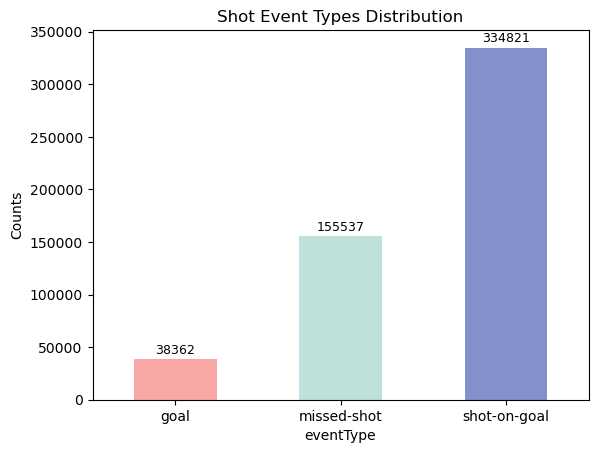

In [273]:

import pandas as pd
import matplotlib.pyplot as plt

# data
csv_path = '/Users/hhhhhhhhh/Desktop/SP_project/data/nhl_shots_data_processed.csv'
df = pd.read_csv(csv_path)

print(df.columns)
shot_counts = df['eventType'].value_counts().sort_index()
print(shot_counts)

# plot
# add number
ax = shot_counts.plot(kind='bar', color=['#f7a7a6', '#c0e0db', '#8390ca'])
ax.bar_label(ax.containers[0], padding=2, fontsize=9)

plt.title('Shot Event Types Distribution')
plt.ylabel('Counts')
plt.grid(False)
plt.xticks(rotation=0)
plt.show()

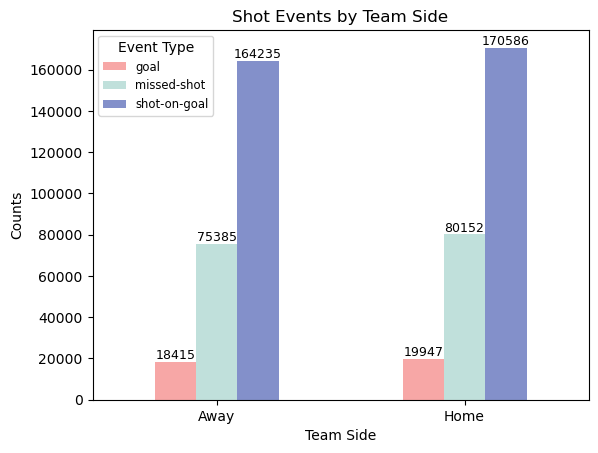

In [274]:
import pandas as pd
import matplotlib.pyplot as plt

# data
df = pd.read_csv('/Users/hhhhhhhhh/Desktop/SP_project/data/nhl_shots_data_processed.csv')

# Home or Away
df['TeamSide'] = 'Away'
df.loc[df['eventOwnerTeamId'] == df['homeTeamId'], 'TeamSide'] = 'Home'

# plot
ax = pd.crosstab(df['TeamSide'], df['eventType']).plot(kind='bar', color=['#f7a7a6', '#c0e0db', '#8390ca'])
for container in ax.containers:
    ax.bar_label(container, fontsize=9)
    
plt.title('Shot Events by Team Side')
plt.ylabel('Counts')
plt.xlabel('Team Side')
plt.xticks(rotation=0)
plt.legend(title='Event Type', loc='upper left', fontsize='small')
plt.grid(False)
plt.show()

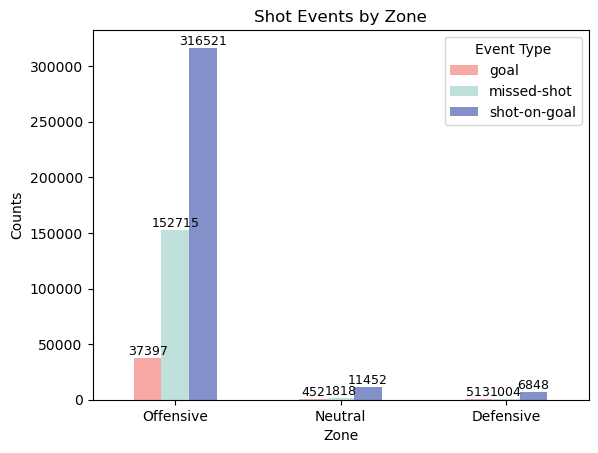

In [275]:
import pandas as pd
import matplotlib.pyplot as plt

zone_map = {'O': 'Offensive', 'N': 'Neutral', 'D': 'Defensive'}
df['Zone'] = df['zoneCode'].map(zone_map)

# https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html
ax = pd.crosstab(df['Zone'], df['eventType']).reindex(['Offensive', 'Neutral', 'Defensive']).plot(kind='bar', color=['#f7a7a6', '#c0e0db', '#8390ca'])

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.title('Shot Events by Zone')
plt.ylabel('Counts')
plt.xlabel('Zone')
plt.xticks(rotation=0)
plt.legend(title='Event Type', loc='upper right')
plt.grid(False)
plt.show()

# Feature engineering


In [276]:
df = pd.read_csv('/Users/hhhhhhhhh/Desktop/SP_project/data/nhl_shots_data_processed.csv')
df.head(5)

,gameId,gameDate,season,homeTeam,awayTeam,homeTeamId,awayTeamId,eventType,period,periodTimeRemaining,homeTeamDefendingSide,zoneCode,xCoord,yCoord,shotType,shootingPlayerId,goalieInNetId,eventOwnerTeamId,sortOrder,periodTimeRemainingSec
0,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,19:52,right,O,56,-39,wrist,8483495.0,8480045.0,1,13,1192
1,2024020001,2024-10-04,20242025,BUF,NJD,7,1,missed-shot,1,19:31,right,O,71,-28,wrist,8479407.0,8480045.0,1,21,1171
2,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,19:20,right,O,47,-23,slap,8476462.0,8480045.0,1,24,1160
3,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,18:58,right,O,-40,-30,wrist,8482175.0,8474593.0,7,31,1138
4,2024020001,2024-10-04,20242025,BUF,NJD,7,1,missed-shot,1,18:54,right,O,-36,15,slap,8482671.0,8474593.0,7,36,1134


In [277]:
print(df.columns)

Index(['gameId', 'gameDate', 'season', 'homeTeam', 'awayTeam', 'homeTeamId',
       'awayTeamId', 'eventType', 'period', 'periodTimeRemaining',
       'homeTeamDefendingSide', 'zoneCode', 'xCoord', 'yCoord', 'shotType',
       'shootingPlayerId', 'goalieInNetId', 'eventOwnerTeamId', 'sortOrder',
       'periodTimeRemainingSec'],
      dtype='str')


# Feature engineering

In [278]:
import numpy as np
import pandas as pd

df = pd.read_csv('/Users/hhhhhhhhh/Desktop/SP_project/data/nhl_shots_data_processed.csv')

# isHomeTeam
df['isHomeTeam'] = (df['eventOwnerTeamId'] == df['homeTeamId']).astype(int)

# home shot
is_home_shot = df['eventOwnerTeamId'] == df['homeTeamId']

home_defend_left = df['homeTeamDefendingSide'] == 'left'

df['target_goal_x'] = np.where(is_home_shot == home_defend_left, 89, -89)

# distance: sqrt((x1 - x2)^2 + (y1 - y2)^2)
df['shotDistance'] = np.sqrt((df['xCoord'] - df['target_goal_x'])**2 + (df['yCoord'] - 0)**2)

dx = (df['target_goal_x'] - df['xCoord']).abs()
dy = df['yCoord'].abs()

df['shotAngle'] = np.degrees(np.arctan2(dy, dx))

df[['eventOwnerTeamId', 'homeTeamDefendingSide', 'xCoord', 'yCoord', 'shotDistance', 'shotAngle']].head(5)

df.head(5)

,gameId,gameDate,season,homeTeam,awayTeam,homeTeamId,awayTeamId,eventType,period,periodTimeRemaining,...,shotType,shootingPlayerId,goalieInNetId,eventOwnerTeamId,sortOrder,periodTimeRemainingSec,isHomeTeam,target_goal_x,shotDistance,shotAngle
0,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,19:52,...,wrist,8483495.0,8480045.0,1,13,1192,0,89,51.088159,49.763642
1,2024020001,2024-10-04,20242025,BUF,NJD,7,1,missed-shot,1,19:31,...,wrist,8479407.0,8480045.0,1,21,1171,0,89,33.286634,57.264774
2,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,19:20,...,slap,8476462.0,8480045.0,1,24,1160,0,89,47.885280,28.705953
3,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,18:58,...,wrist,8482175.0,8474593.0,7,31,1138,1,-89,57.454330,31.476839
4,2024020001,2024-10-04,20242025,BUF,NJD,7,1,missed-shot,1,18:54,...,slap,8482671.0,8474593.0,7,36,1134,1,-89,55.081757,15.802514


In [279]:
print(df.columns)

Index(['gameId', 'gameDate', 'season', 'homeTeam', 'awayTeam', 'homeTeamId',
       'awayTeamId', 'eventType', 'period', 'periodTimeRemaining',
       'homeTeamDefendingSide', 'zoneCode', 'xCoord', 'yCoord', 'shotType',
       'shootingPlayerId', 'goalieInNetId', 'eventOwnerTeamId', 'sortOrder',
       'periodTimeRemainingSec', 'isHomeTeam', 'target_goal_x', 'shotDistance',
       'shotAngle'],
      dtype='str')


In [280]:
df.to_csv('/Users/hhhhhhhhh/Desktop/SP_project/data/nhl_shots_data_featured.csv', index=False)

In [281]:
df.head(5)

,gameId,gameDate,season,homeTeam,awayTeam,homeTeamId,awayTeamId,eventType,period,periodTimeRemaining,...,shotType,shootingPlayerId,goalieInNetId,eventOwnerTeamId,sortOrder,periodTimeRemainingSec,isHomeTeam,target_goal_x,shotDistance,shotAngle
0,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,19:52,...,wrist,8483495.0,8480045.0,1,13,1192,0,89,51.088159,49.763642
1,2024020001,2024-10-04,20242025,BUF,NJD,7,1,missed-shot,1,19:31,...,wrist,8479407.0,8480045.0,1,21,1171,0,89,33.286634,57.264774
2,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,19:20,...,slap,8476462.0,8480045.0,1,24,1160,0,89,47.885280,28.705953
3,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,18:58,...,wrist,8482175.0,8474593.0,7,31,1138,1,-89,57.454330,31.476839
4,2024020001,2024-10-04,20242025,BUF,NJD,7,1,missed-shot,1,18:54,...,slap,8482671.0,8474593.0,7,36,1134,1,-89,55.081757,15.802514


# Manual encoding

In [282]:
df = pd.read_csv('/Users/hhhhhhhhh/Desktop/SP_project/data/nhl_shots_data_featured.csv')
print(df.columns)
df.head(5)

Index(['gameId', 'gameDate', 'season', 'homeTeam', 'awayTeam', 'homeTeamId',
       'awayTeamId', 'eventType', 'period', 'periodTimeRemaining',
       'homeTeamDefendingSide', 'zoneCode', 'xCoord', 'yCoord', 'shotType',
       'shootingPlayerId', 'goalieInNetId', 'eventOwnerTeamId', 'sortOrder',
       'periodTimeRemainingSec', 'isHomeTeam', 'target_goal_x', 'shotDistance',
       'shotAngle'],
      dtype='str')


,gameId,gameDate,season,homeTeam,awayTeam,homeTeamId,awayTeamId,eventType,period,periodTimeRemaining,...,shotType,shootingPlayerId,goalieInNetId,eventOwnerTeamId,sortOrder,periodTimeRemainingSec,isHomeTeam,target_goal_x,shotDistance,shotAngle
0,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,19:52,...,wrist,8483495.0,8480045.0,1,13,1192,0,89,51.088159,49.763642
1,2024020001,2024-10-04,20242025,BUF,NJD,7,1,missed-shot,1,19:31,...,wrist,8479407.0,8480045.0,1,21,1171,0,89,33.286634,57.264774
2,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,19:20,...,slap,8476462.0,8480045.0,1,24,1160,0,89,47.885280,28.705953
3,2024020001,2024-10-04,20242025,BUF,NJD,7,1,shot-on-goal,1,18:58,...,wrist,8482175.0,8474593.0,7,31,1138,1,-89,57.454330,31.476839
4,2024020001,2024-10-04,20242025,BUF,NJD,7,1,missed-shot,1,18:54,...,slap,8482671.0,8474593.0,7,36,1134,1,-89,55.081757,15.802514


In [283]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Users/hhhhhhhhh/Desktop/SP_project/data/nhl_shots_data_featured.csv')

event_type_map = {
    'shot-on-goal': 0, 
    'missed-shot': 1, 
    'goal': 2,
}

# manual mapping
defending_side_map = {'left': 0, 'right': 1}

zone_map = {
    'O': 0, # Offensive
    'D': 1, # Defensive
    'N': 2  # Neutral
}

shot_type_map = {
    'wrist': 0, 
    'slap': 1, 
    'snap': 2, 
    'backhand': 3, 
    'tip-in': 4, 
    'wrap-around': 5, 
    'deflected': 6, 
    'poke': 7, 
    'bat': 8, 
    'cradle': 9, 
    'between-legs': 10
}


df['eventType'] = df['eventType'].map(event_type_map)
df['homeTeamDefendingSide'] = df['homeTeamDefendingSide'].map(defending_side_map)
df['zoneCode'] = df['zoneCode'].map(zone_map)
df['shotType'] = df['shotType'].map(shot_type_map)


['gameId', 'gameDate', 'season', 'homeTeam', 'awayTeam', 'homeTeamId',
       'awayTeamId', 'eventType', 'period', 'periodTimeRemaining',
       'homeTeamDefendingSide', 'zoneCode', 'xCoord', 'yCoord', 'shotType',
       'shootingPlayerId', 'goalieInNetId', 'eventOwnerTeamId', 'sortOrder',
       'periodTimeRemainingSec', 'isHomeTeam', 'target_goal_x', 'shotDistance',
       'shotAngle']

In [284]:
print(df['eventType'].unique())
print(df['period'].unique())
print(df['periodTimeRemainingSec'].unique())
print(df['homeTeamDefendingSide'].unique())
print(df['zoneCode'].unique())
print(df['xCoord'].unique())
print(df['yCoord'].unique())
print(df['shotType'].unique())
print(df['isHomeTeam'].unique())
print(df['shotDistance'].unique())
print(df['shotAngle'].unique())

[0 1 2]
[1 2 3 4 5]
[1192 1171 1160 ... 1198 1194 1199]
[1 0]
[0 1 2]
[ 56  71  47 -40 -36  79  96 -86 -53 -67 -58 -92 -82  34  82  87  43  59
  70  38 -60 -65 -76  78  51 -51 -56  69 -69  81 -41 -95 -50 -77  55  48
  52  57  63  60  73  54 -78 -57 -70 -63  45  28 -29 -72  76  35 -61 -43
 -66 -85 -38 -83 -47 -55  67 -81 -32 -42 -34 -87 -88 -27  80  74  64  21
  91 -46 -28  86  68  31 -49 -74  44 -68 -64  84 -73 -54 -84  27 -71  93
  29 -45 -80  50 -79  58 -33 -39  90 -35  75 -37 -44  72 -11 -52 -75 -48
  40  85  33 -59  16  32  30  53 -90   2  77 -62 -91  62  36  88  61  41
  83  26   0  42   8  25 -30 -26  66 -18   6 -97  37  89  14 -89  -7  -4
  39  49 -31  46  -3   5  65  19   7  24 -10 -13  11  98   1  94 -24   4
  22   3  23  18 -17  92 -93 -25  -2  -9  99  10  12  17  13  95 -12 -22
 -21   9 -98 -99 -94  -6 -23 -19  20  -1  -8 -16 -15  -5 -20 -14  97 -96
  15]
[-39 -28 -23 -30  15   2  11  17  26 -16   5  22 -12  14  -7  28  19   0
   1  -3 -34  27 -25  25 -29   7  24  -5  -9   3

In [285]:
df.to_csv('/Users/hhhhhhhhh/Desktop/SP_project/data/nhl_shots_data_encoded.csv', index=False)

In [286]:
csv_path = '/Users/hhhhhhhhh/Desktop/SP_project/data/nhl_shots_data_encoded.csv'
df = pd.read_csv(csv_path)
print(df.columns)
df.head(5)

Index(['gameId', 'gameDate', 'season', 'homeTeam', 'awayTeam', 'homeTeamId',
       'awayTeamId', 'eventType', 'period', 'periodTimeRemaining',
       'homeTeamDefendingSide', 'zoneCode', 'xCoord', 'yCoord', 'shotType',
       'shootingPlayerId', 'goalieInNetId', 'eventOwnerTeamId', 'sortOrder',
       'periodTimeRemainingSec', 'isHomeTeam', 'target_goal_x', 'shotDistance',
       'shotAngle'],
      dtype='str')


,gameId,gameDate,season,homeTeam,awayTeam,homeTeamId,awayTeamId,eventType,period,periodTimeRemaining,...,shotType,shootingPlayerId,goalieInNetId,eventOwnerTeamId,sortOrder,periodTimeRemainingSec,isHomeTeam,target_goal_x,shotDistance,shotAngle
0,2024020001,2024-10-04,20242025,BUF,NJD,7,1,0,1,19:52,...,0,8483495.0,8480045.0,1,13,1192,0,89,51.088159,49.763642
1,2024020001,2024-10-04,20242025,BUF,NJD,7,1,1,1,19:31,...,0,8479407.0,8480045.0,1,21,1171,0,89,33.286634,57.264774
2,2024020001,2024-10-04,20242025,BUF,NJD,7,1,0,1,19:20,...,1,8476462.0,8480045.0,1,24,1160,0,89,47.885280,28.705953
3,2024020001,2024-10-04,20242025,BUF,NJD,7,1,0,1,18:58,...,0,8482175.0,8474593.0,7,31,1138,1,-89,57.454330,31.476839
4,2024020001,2024-10-04,20242025,BUF,NJD,7,1,1,1,18:54,...,1,8482671.0,8474593.0,7,36,1134,1,-89,55.081757,15.802514


# Methods

We select 'eventType' as y, and others like 'period', 'periodTimeRemaining', 'homeTeamDefendingSide', 'zoneCode', 'xCoord', 'yCoord', 'shotType' as X.



In [287]:

y = ['eventType']
x = ['period','homeTeamDefendingSide', 'zoneCode', 'xCoord', 'yCoord', 'shotType','periodTimeRemainingSec', 'isHomeTeam', 'shotDistance','shotAngle']

# data split

In [288]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

random_state = 123

# read data
df = pd.read_csv('/Users/hhhhhhhhh/Desktop/SP_project/data/nhl_shots_data_encoded.csv')

# features and prediction
features = ['period', 'homeTeamDefendingSide', 'zoneCode', 'xCoord', 'yCoord', 
          'shotType', 'periodTimeRemainingSec', 'isHomeTeam', 'shotDistance', 'shotAngle']
prediction = 'eventType'

# data split
# https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
X = df[features]
y = df[prediction]

# 20% test, 80% train and val
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)



In [289]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts())
print(y_test.value_counts(normalize=True) * 100)

eventType
0    267712
1    124606
2     30658
Name: count, dtype: int64
eventType
0    63.292480
1    29.459355
2     7.248165
Name: proportion, dtype: float64
eventType
0    67109
1    30931
2     7704
Name: count, dtype: int64
eventType
0    63.463648
1    29.250832
2     7.285520
Name: proportion, dtype: float64


# Classification

# 

# Logistic Regression

## training Logistic Regression

In [290]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report

# make_pipeline
# StandardScaler
# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html

# Logistic Regression
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

estimator = make_pipeline(StandardScaler(), LogisticRegression(C=5, max_iter=1000, class_weight='balanced', random_state = random_state))

scores = cross_validate(estimator, X_train, y_train, cv=5,
                           scoring=('balanced_accuracy', 'f1_weighted', 'recall_weighted', 'roc_auc_ovo_weighted'),
                           return_train_score=True)

print(scores)
print('------------------------------------------------------------------')

print('train_balanced_accuracy:', round(scores['train_balanced_accuracy'].mean(), 4))
print('val_balanced_accuracy:', round(scores['test_balanced_accuracy'].mean(), 4))
print('------------------------------------------------------------------')

print('train_f1_weighted:', round(scores['train_f1_weighted'].mean(), 4))
print('val_f1_weighted:', round(scores['test_f1_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_recall_weighted:', round(scores['train_recall_weighted'].mean(), 4))
print('val_recall_weighted:', round(scores['test_recall_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_roc_auc_ovo_weighted:', round(scores['train_roc_auc_ovo_weighted'].mean(), 4))
print('val_roc_auc_ovo_weighted:', round(scores['test_roc_auc_ovo_weighted'].mean(), 4))
print('------------------------------------------------------------------')

estimator.fit(X_train, y_train)



{'fit_time': array([0.54539895, 0.50484896, 0.49019575, 0.47528195, 0.50884199]), 'score_time': array([0.11780524, 0.10945296, 0.13131404, 0.11067486, 0.11392498]), 'test_balanced_accuracy': array([0.46478834, 0.45848532, 0.45625528, 0.45990728, 0.4590035 ]), 'train_balanced_accuracy': array([0.45868459, 0.45983748, 0.46092967, 0.46021007, 0.4601968 ]), 'test_f1_weighted': array([0.40551282, 0.4066112 , 0.40460149, 0.40463331, 0.40516512]), 'train_f1_weighted': array([0.40662705, 0.40565106, 0.40526414, 0.40437795, 0.40530615]), 'test_recall_weighted': array([0.37378836, 0.37382824, 0.37181867, 0.37255157, 0.37218512]), 'train_recall_weighted': array([0.37365388, 0.37314152, 0.37291692, 0.37232291, 0.37289919]), 'test_roc_auc_ovo_weighted': array([0.63004336, 0.62817064, 0.62628395, 0.62760679, 0.62694192]), 'train_roc_auc_ovo_weighted': array([0.62738768, 0.62774007, 0.62848931, 0.62787603, 0.62823171])}
------------------------------------------------------------------
train_balanced

,steps,"[('standardscaler', ...), ('logisticregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,5


## test Logistic Regression

In [291]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

# predict the labels of the test set
y_pred = estimator.predict(X_test)

print(classification_report(y_test, y_pred, labels=[0, 1, 2], target_names=['shot-on-goal', 'missed-shot', 'goal']))

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
test_auc = roc_auc_score(y_test, estimator.predict_proba(X_test), multi_class='ovo', average='weighted')

print('test_roc_auc_ovo_weighted:', round(test_auc, 4))

# confusion matrix
confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

shot-on-goal       0.69      0.33      0.44     67109
 missed-shot       0.34      0.41      0.37     30931
        goal       0.13      0.64      0.22      7704

    accuracy                           0.37    105744
   macro avg       0.39      0.46      0.34    105744
weighted avg       0.55      0.37      0.40    105744

test_roc_auc_ovo_weighted: 0.6266


array([[21822, 23075, 22212],
       [ 8557, 12589,  9785],
       [ 1175,  1567,  4962]])

## Confusion Matrix Logistic Regression

Confusion matrix, without normalization
[[21822 23075 22212]
 [ 8557 12589  9785]
 [ 1175  1567  4962]]
Normalized confusion matrix
[[0.32517248 0.3438436  0.33098392]
 [0.27664802 0.40700268 0.31634929]
 [0.15251817 0.20340083 0.644081  ]]


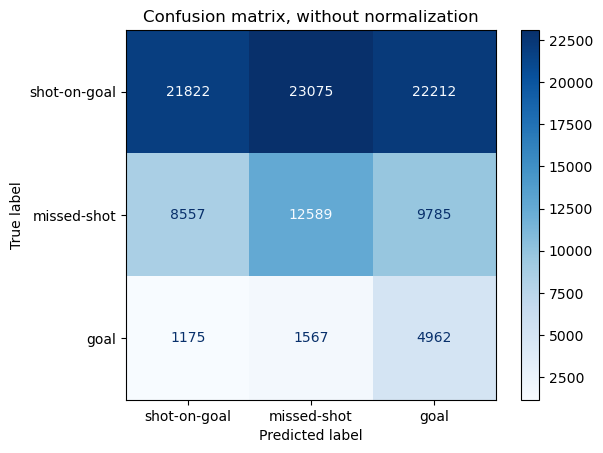

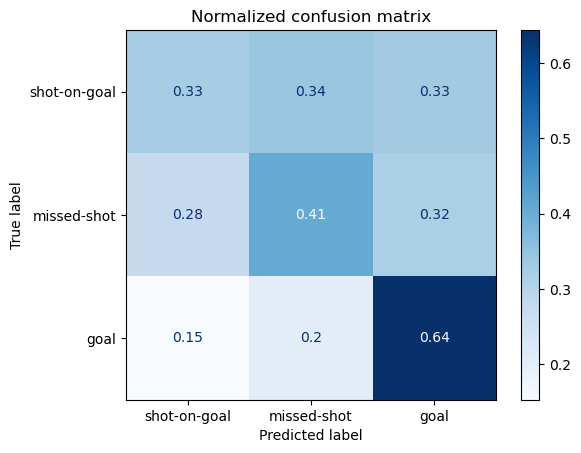

In [292]:
# Evaluate the performance of a classifier with Confusion Matrix

# https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

target_names=['shot-on-goal', 'missed-shot', 'goal']
class_names = target_names

# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        estimator,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

# Random Forest Classifier

## training Random Forest Classifier

In [293]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report

# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
estimator = RandomForestClassifier(random_state=random_state, class_weight='balanced')

scores = cross_validate(estimator, X_train, y_train, cv=5,
                           scoring=('balanced_accuracy', 'f1_weighted', 'recall_weighted', 'roc_auc_ovo_weighted'),
                           return_train_score=True)

print(scores)
print('------------------------------------------------------------------')

print('train_balanced_accuracy:', round(scores['train_balanced_accuracy'].mean(), 4))
print('val_balanced_accuracy:', round(scores['test_balanced_accuracy'].mean(), 4))
print('------------------------------------------------------------------')

print('train_f1_weighted:', round(scores['train_f1_weighted'].mean(), 4))
print('val_f1_weighted:', round(scores['test_f1_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_recall_weighted:', round(scores['train_recall_weighted'].mean(), 4))
print('val_recall_weighted:', round(scores['test_recall_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_roc_auc_ovo_weighted:', round(scores['train_roc_auc_ovo_weighted'].mean(), 4))
print('val_roc_auc_ovo_weighted:', round(scores['test_roc_auc_ovo_weighted'].mean(), 4))
print('------------------------------------------------------------------')


estimator.fit(X_train, y_train)



{'fit_time': array([42.08716106, 42.26957583, 43.44506764, 44.19455314, 42.5374012 ]), 'score_time': array([5.95272803, 5.31435013, 5.55353427, 6.09898186, 5.05896187]), 'test_balanced_accuracy': array([0.36600731, 0.36448754, 0.36487512, 0.3661039 , 0.36646539]), 'train_balanced_accuracy': array([0.99864347, 0.99867226, 0.99864304, 0.99865849, 0.99852379]), 'test_f1_weighted': array([0.54249697, 0.54214823, 0.5399697 , 0.54339353, 0.54320483]), 'train_f1_weighted': array([0.99817207, 0.99819832, 0.99814247, 0.99812793, 0.99810444]), 'test_recall_weighted': array([0.58265166, 0.58372244, 0.57990425, 0.58375791, 0.58388794]), 'train_recall_weighted': array([0.99816774, 0.99819434, 0.99813819, 0.99812342, 0.99809978]), 'test_roc_auc_ovo_weighted': array([0.59062447, 0.59257093, 0.59055758, 0.59182432, 0.59186917]), 'train_roc_auc_ovo_weighted': array([0.99968403, 0.99970575, 0.99970846, 0.99969185, 0.99966218])}
------------------------------------------------------------------
train_bal

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## training Random Forest Classifier, solve the over fitting

In [294]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report

# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
estimator = RandomForestClassifier(n_estimators=200, random_state=random_state, 
                                   max_depth=15, min_samples_leaf=30, max_features='sqrt', class_weight='balanced')

scores = cross_validate(estimator, X_train, y_train, cv=5,
                           scoring=('balanced_accuracy', 'f1_weighted', 'recall_weighted', 'roc_auc_ovo_weighted'),
                           return_train_score=True)

print(scores)
print('------------------------------------------------------------------')

print('train_balanced_accuracy:', round(scores['train_balanced_accuracy'].mean(), 4))
print('val_balanced_accuracy:', round(scores['test_balanced_accuracy'].mean(), 4))
print('------------------------------------------------------------------')

print('train_f1_weighted:', round(scores['train_f1_weighted'].mean(), 4))
print('val_f1_weighted:', round(scores['test_f1_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_recall_weighted:', round(scores['train_recall_weighted'].mean(), 4))
print('val_recall_weighted:', round(scores['test_recall_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_roc_auc_ovo_weighted:', round(scores['train_roc_auc_ovo_weighted'].mean(), 4))
print('val_roc_auc_ovo_weighted:', round(scores['test_roc_auc_ovo_weighted'].mean(), 4))
print('------------------------------------------------------------------')

estimator.fit(X_train, y_train)


{'fit_time': array([49.77488613, 50.68215489, 49.68576694, 50.23677206, 52.48408127]), 'score_time': array([3.06953073, 3.10269403, 3.07506108, 3.22045994, 3.13968086]), 'test_balanced_accuracy': array([0.49385481, 0.49178852, 0.48713488, 0.48843356, 0.49164623]), 'train_balanced_accuracy': array([0.55158771, 0.55275492, 0.55042829, 0.55321052, 0.55445717]), 'test_f1_weighted': array([0.43616886, 0.43280981, 0.43150253, 0.43408062, 0.43667517]), 'train_f1_weighted': array([0.48247619, 0.47851349, 0.47937207, 0.48414994, 0.4855127 ]), 'test_recall_weighted': array([0.40682775, 0.40383001, 0.40283705, 0.40433832, 0.40743543]), 'train_recall_weighted': array([0.45188841, 0.44865403, 0.44945786, 0.45342676, 0.45565206]), 'test_roc_auc_ovo_weighted': array([0.6629491 , 0.66259219, 0.66104892, 0.66040227, 0.66159544]), 'train_roc_auc_ovo_weighted': array([0.71119931, 0.71098752, 0.71132338, 0.71106937, 0.71120941])}
------------------------------------------------------------------
train_bal

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,30
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [295]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report

# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
estimator = RandomForestClassifier(random_state=random_state,max_depth=12,min_samples_leaf=50,max_features='sqrt', class_weight='balanced')

scores = cross_validate(estimator, X_train, y_train, cv=5,
                           scoring=('balanced_accuracy', 'f1_weighted', 'recall_weighted', 'roc_auc_ovo_weighted'),
                           return_train_score=True)

print(scores)
print('------------------------------------------------------------------')

print('train_balanced_accuracy:', round(scores['train_balanced_accuracy'].mean(), 4))
print('val_balanced_accuracy:', round(scores['test_balanced_accuracy'].mean(), 4))
print('------------------------------------------------------------------')

print('train_f1_weighted:', round(scores['train_f1_weighted'].mean(), 4))
print('val_f1_weighted:', round(scores['test_f1_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_recall_weighted:', round(scores['train_recall_weighted'].mean(), 4))
print('val_recall_weighted:', round(scores['test_recall_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_roc_auc_ovo_weighted:', round(scores['train_roc_auc_ovo_weighted'].mean(), 4))
print('val_roc_auc_ovo_weighted:', round(scores['test_roc_auc_ovo_weighted'].mean(), 4))
print('------------------------------------------------------------------')

estimator.fit(X_train, y_train)


{'fit_time': array([22.1151197 , 21.355551  , 21.59548283, 22.00260878, 22.34542012]), 'score_time': array([1.26860714, 1.17293811, 1.2009263 , 1.20064521, 1.27226901]), 'test_balanced_accuracy': array([0.49193208, 0.49350472, 0.48938509, 0.49143318, 0.4930518 ]), 'train_balanced_accuracy': array([0.51705318, 0.51776799, 0.51647281, 0.51794554, 0.51747254]), 'test_f1_weighted': array([0.41433982, 0.41227866, 0.40931897, 0.41217104, 0.41586114]), 'train_f1_weighted': array([0.43469192, 0.42738632, 0.42957885, 0.43218154, 0.43499343]), 'test_recall_weighted': array([0.38729964, 0.38615757, 0.38404161, 0.38580294, 0.38904191]), 'train_recall_weighted': array([0.40682073, 0.40143211, 0.40355694, 0.4054217 , 0.4080962 ]), 'test_roc_auc_ovo_weighted': array([0.66325219, 0.66283941, 0.66112057, 0.66085803, 0.6622323 ]), 'train_roc_auc_ovo_weighted': array([0.68239807, 0.68248055, 0.68262957, 0.682618  , 0.68263655])}
------------------------------------------------------------------
train_bal

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## test Random Forest Classifier

In [296]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

# predict the labels of the test set
y_pred = estimator.predict(X_test)

print(classification_report(y_test, y_pred, labels=[0, 1, 2], target_names=['shot-on-goal', 'missed-shot', 'goal']))

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
test_auc = roc_auc_score(y_test, estimator.predict_proba(X_test), multi_class='ovo', average='weighted')

print('test_roc_auc_ovo_weighted:', round(test_auc, 4))

# confusion matrix
confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

shot-on-goal       0.71      0.31      0.43     67109
 missed-shot       0.37      0.48      0.42     30931
        goal       0.15      0.70      0.24      7704

    accuracy                           0.39    105744
   macro avg       0.41      0.49      0.36    105744
weighted avg       0.57      0.39      0.41    105744

test_roc_auc_ovo_weighted: 0.6637


array([[20557, 23852, 22700],
       [ 7283, 14916,  8732],
       [  948,  1392,  5364]])

## Confusion Matrix Random Forest Classifier

Confusion matrix
[[20557 23852 22700]
 [ 7283 14916  8732]
 [  948  1392  5364]]
Normalized confusion matrix
[[0.30632255 0.35542178 0.33825567]
 [0.23545957 0.48223465 0.28230578]
 [0.12305296 0.18068536 0.69626168]]


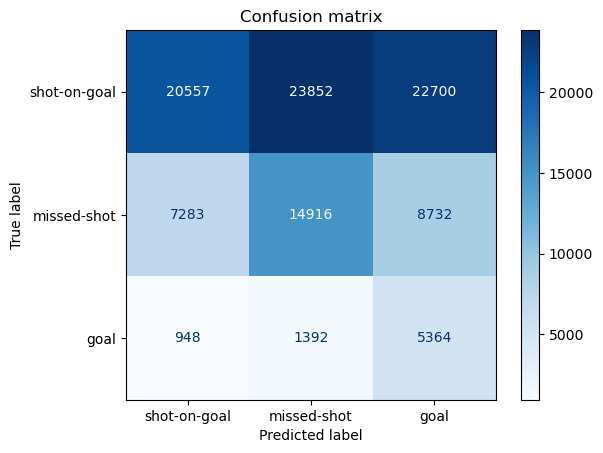

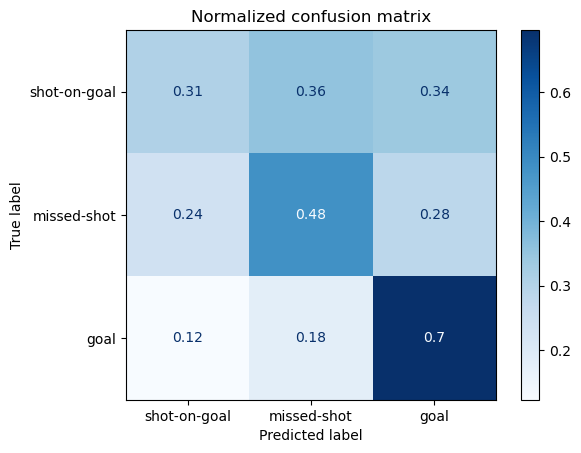

In [297]:
# Evaluate the performance of a classifier with Confusion Matrix

# https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

target_names=['shot-on-goal', 'missed-shot', 'goal']
class_names = target_names

# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        estimator,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

# Hist Gradient Boosting Classifier

## training Hist Gradient Boosting Classifier

In [298]:
from sklearn.ensemble import HistGradientBoostingClassifier

# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html
estimator = HistGradientBoostingClassifier(learning_rate=0.01,max_iter=300,max_leaf_nodes=50, max_depth=15,
                                           l2_regularization=1.0, min_samples_leaf=50,
                                           random_state=random_state, class_weight='balanced')

scores = cross_validate(estimator, X_train, y_train, cv=5,
                           scoring=('balanced_accuracy', 'f1_weighted', 'recall_weighted', 'roc_auc_ovo_weighted'),
                           return_train_score=True)

print(scores)
print('------------------------------------------------------------------')

print('train_balanced_accuracy:', round(scores['train_balanced_accuracy'].mean(), 4))
print('val_balanced_accuracy:', round(scores['test_balanced_accuracy'].mean(), 4))
print('------------------------------------------------------------------')

print('train_f1_weighted:', round(scores['train_f1_weighted'].mean(), 4))
print('val_f1_weighted:', round(scores['test_f1_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_recall_weighted:', round(scores['train_recall_weighted'].mean(), 4))
print('val_recall_weighted:', round(scores['test_recall_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_roc_auc_ovo_weighted:', round(scores['train_roc_auc_ovo_weighted'].mean(), 4))
print('val_roc_auc_ovo_weighted:', round(scores['test_roc_auc_ovo_weighted'].mean(), 4))
print('------------------------------------------------------------------')

estimator.fit(X_train, y_train)


{'fit_time': array([20.4692781 , 20.46199298, 19.98076105, 22.58826685, 23.90694213]), 'score_time': array([1.97076797, 2.1830132 , 1.96226621, 1.97134709, 2.03771996]), 'test_balanced_accuracy': array([0.49664873, 0.49426881, 0.49095697, 0.49238393, 0.49653892]), 'train_balanced_accuracy': array([0.50427551, 0.50375419, 0.50417869, 0.50454715, 0.50357405]), 'test_f1_weighted': array([0.42248537, 0.42014264, 0.41942478, 0.4225243 , 0.42332094]), 'train_f1_weighted': array([0.43212951, 0.42417343, 0.42776229, 0.43169744, 0.42922781]), 'test_recall_weighted': array([0.39413211, 0.39220994, 0.39170164, 0.39378214, 0.39491696]), 'train_recall_weighted': array([0.40277203, 0.3965796 , 0.39980082, 0.40271765, 0.40098587]), 'test_roc_auc_ovo_weighted': array([0.66613111, 0.66514422, 0.66445111, 0.66399241, 0.66541478]), 'train_roc_auc_ovo_weighted': array([0.67441467, 0.67470474, 0.67490191, 0.67488377, 0.67481373])}
------------------------------------------------------------------
train_bal

,loss,'log_loss'
,learning_rate,0.01
,max_iter,300
,max_leaf_nodes,50
,max_depth,15
,min_samples_leaf,50
,l2_regularization,1.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [299]:
from sklearn.ensemble import HistGradientBoostingClassifier

# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingClassifier.html
estimator = HistGradientBoostingClassifier(learning_rate=0.05, random_state=random_state, class_weight='balanced')

scores = cross_validate(estimator, X_train, y_train, cv=5,
                           scoring=('balanced_accuracy', 'f1_weighted', 'recall_weighted', 'roc_auc_ovo_weighted'),
                           return_train_score=True)

print(scores)
print('------------------------------------------------------------------')

print('train_balanced_accuracy:', round(scores['train_balanced_accuracy'].mean(), 4))
print('val_balanced_accuracy:', round(scores['test_balanced_accuracy'].mean(), 4))
print('------------------------------------------------------------------')

print('train_f1_weighted:', round(scores['train_f1_weighted'].mean(), 4))
print('val_f1_weighted:', round(scores['test_f1_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_recall_weighted:', round(scores['train_recall_weighted'].mean(), 4))
print('val_recall_weighted:', round(scores['test_recall_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_roc_auc_ovo_weighted:', round(scores['train_roc_auc_ovo_weighted'].mean(), 4))
print('val_roc_auc_ovo_weighted:', round(scores['test_roc_auc_ovo_weighted'].mean(), 4))
print('------------------------------------------------------------------')

estimator.fit(X_train, y_train)


{'fit_time': array([4.30191588, 4.46336794, 5.13525796, 4.5198288 , 4.43169999]), 'score_time': array([0.52109218, 0.54818892, 0.54837799, 0.56574297, 0.53859997]), 'test_balanced_accuracy': array([0.49669711, 0.49496438, 0.49096595, 0.49363639, 0.49615063]), 'train_balanced_accuracy': array([0.50249003, 0.50327297, 0.50323712, 0.50355128, 0.50257756]), 'test_f1_weighted': array([0.42263303, 0.42200951, 0.41877283, 0.42203823, 0.4237034 ]), 'train_f1_weighted': array([0.43047845, 0.42490609, 0.42593237, 0.42907154, 0.42884237]), 'test_recall_weighted': array([0.3945813 , 0.3938176 , 0.39129972, 0.39355754, 0.39497606]), 'train_recall_weighted': array([0.40150718, 0.39716473, 0.39822567, 0.40056918, 0.40038004]), 'test_roc_auc_ovo_weighted': array([0.66619221, 0.66519647, 0.66440837, 0.6640316 , 0.66551027]), 'train_roc_auc_ovo_weighted': array([0.67348444, 0.67501549, 0.67510002, 0.67505975, 0.67447574])}
------------------------------------------------------------------
train_balanced

,loss,'log_loss'
,learning_rate,0.05
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


## test Hist Gradient Boosting Classifier

In [300]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

# predict the labels of the test set
y_pred = estimator.predict(X_test)

print(classification_report(y_test, y_pred, labels=[0, 1, 2], target_names=['shot-on-goal', 'missed-shot', 'goal']))

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
test_auc = roc_auc_score(y_test, estimator.predict_proba(X_test), multi_class='ovo', average='weighted')

print('test_roc_auc_ovo_weighted:', round(test_auc, 4))

# confusion matrix
confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

shot-on-goal       0.72      0.32      0.45     67109
 missed-shot       0.37      0.48      0.42     30931
        goal       0.15      0.69      0.24      7704

    accuracy                           0.40    105744
   macro avg       0.41      0.50      0.37    105744
weighted avg       0.57      0.40      0.42    105744

test_roc_auc_ovo_weighted: 0.6663


array([[21777, 23399, 21933],
       [ 7645, 14793,  8493],
       [ 1012,  1382,  5310]])

## Confusion Matrix Hist Gradient Boosting Classifier

Confusion matrix
[[21777 23399 21933]
 [ 7645 14793  8493]
 [ 1012  1382  5310]]
Normalized confusion matrix
[[0.32450193 0.34867156 0.32682651]
 [0.24716304 0.47825806 0.2745789 ]
 [0.13136033 0.17938733 0.68925234]]


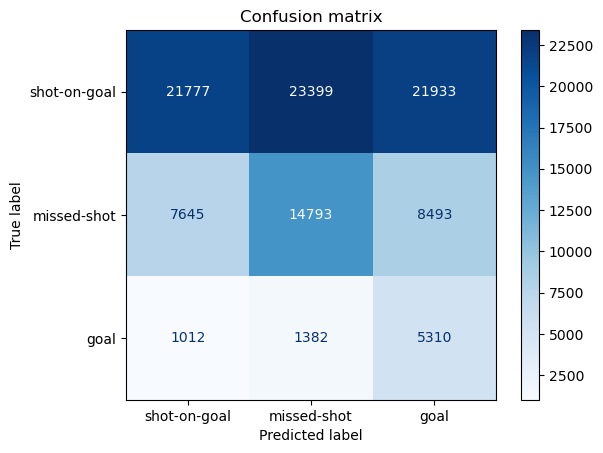

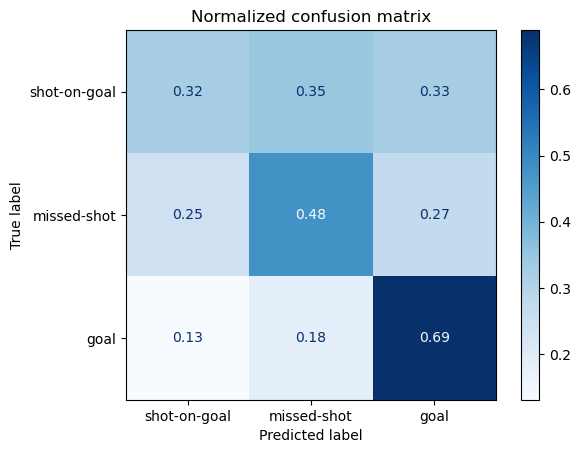

In [301]:
# Evaluate the performance of a classifier with Confusion Matrix

# https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

target_names=['shot-on-goal', 'missed-shot', 'goal']
class_names = target_names

# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        estimator,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

# XGBClassifier

In [302]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

# https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_sample_weight.html
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# https://xgboost.readthedocs.io/en/latest/python/sklearn_estimator.html#overview
estimator = xgb.XGBClassifier(tree_method="hist", learning_rate=0.05, random_state=random_state)
    
scores = cross_validate(estimator, X_train, y_train, cv=5,
                           scoring=('balanced_accuracy', 'f1_weighted', 'recall_weighted', 'roc_auc_ovo_weighted'),
                           return_train_score=True, params={'sample_weight': sample_weights})

print(scores)
print('------------------------------------------------------------------')

print('train_balanced_accuracy:', round(scores['train_balanced_accuracy'].mean(), 4))
print('val_balanced_accuracy:', round(scores['test_balanced_accuracy'].mean(), 4))
print('------------------------------------------------------------------')

print('train_f1_weighted:', round(scores['train_f1_weighted'].mean(), 4))
print('val_f1_weighted:', round(scores['test_f1_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_recall_weighted:', round(scores['train_recall_weighted'].mean(), 4))
print('val_recall_weighted:', round(scores['test_recall_weighted'].mean(), 4))
print('------------------------------------------------------------------')

print('train_roc_auc_ovo_weighted:', round(scores['train_roc_auc_ovo_weighted'].mean(), 4))
print('val_roc_auc_ovo_weighted:', round(scores['test_roc_auc_ovo_weighted'].mean(), 4))
print('------------------------------------------------------------------')

estimator.fit(X_train, y_train, sample_weight=sample_weights)


{'fit_time': array([2.02579403, 2.0319171 , 2.05513501, 2.12744403, 2.11089706]), 'score_time': array([0.17115498, 0.17002583, 0.16770196, 0.20042706, 0.17104793]), 'test_balanced_accuracy': array([0.494123  , 0.49454621, 0.49168378, 0.49317111, 0.49578832]), 'train_balanced_accuracy': array([0.50134128, 0.50244584, 0.50310055, 0.50277392, 0.50203534]), 'test_f1_weighted': array([0.41940189, 0.42007552, 0.41716979, 0.41930995, 0.41942109]), 'train_f1_weighted': array([0.42875177, 0.42309271, 0.4244315 , 0.42620169, 0.42513784]), 'test_recall_weighted': array([0.39103504, 0.39142975, 0.38951475, 0.39074413, 0.39105148]), 'train_recall_weighted': array([0.39930256, 0.39499263, 0.39636977, 0.39753414, 0.3968367 ]), 'test_roc_auc_ovo_weighted': array([0.6656786 , 0.66536733, 0.66418047, 0.66401965, 0.66522905]), 'train_roc_auc_ovo_weighted': array([0.6728342 , 0.67293122, 0.67316101, 0.67327818, 0.67295502])}
------------------------------------------------------------------
train_balanced

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## test XGBClassifier 

In [303]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html

# predict the labels of the test set
y_pred = estimator.predict(X_test)

print(classification_report(y_test, y_pred, labels=[0, 1, 2], target_names=['shot-on-goal', 'missed-shot', 'goal']))

# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
test_auc = roc_auc_score(y_test, estimator.predict_proba(X_test), multi_class='ovo', average='weighted')

print('test_roc_auc_ovo_weighted:', round(test_auc, 4))

# confusion matrix
confusion_matrix(y_test, y_pred)


              precision    recall  f1-score   support

shot-on-goal       0.72      0.32      0.44     67109
 missed-shot       0.37      0.47      0.42     30931
        goal       0.15      0.70      0.24      7704

    accuracy                           0.39    105744
   macro avg       0.41      0.50      0.37    105744
weighted avg       0.58      0.39      0.42    105744

test_roc_auc_ovo_weighted: 0.6664


array([[21451, 23117, 22541],
       [ 7482, 14678,  8771],
       [  944,  1359,  5401]])

Confusion matrix
[[21451 23117 22541]
 [ 7482 14678  8771]
 [  944  1359  5401]]
Normalized confusion matrix
[[0.31964416 0.34446945 0.33588639]
 [0.24189325 0.47454011 0.28356665]
 [0.12253375 0.17640187 0.70106438]]


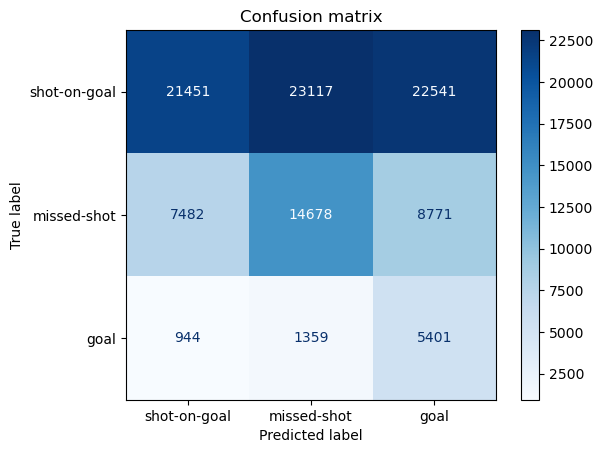

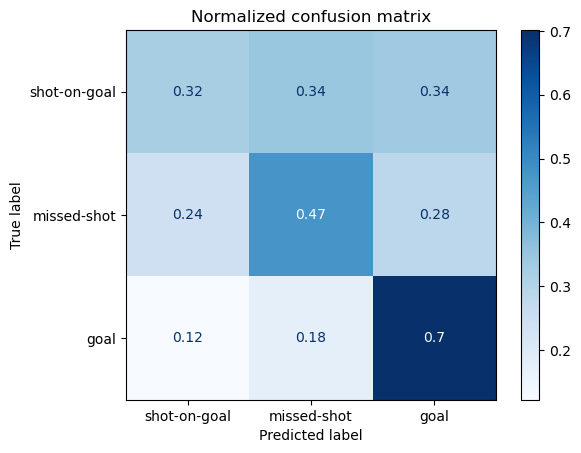

In [304]:
# Evaluate the performance of a classifier with Confusion Matrix

# https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

target_names=['shot-on-goal', 'missed-shot', 'goal']
class_names = target_names

# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        estimator,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()